Data Preprocessing

In [62]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv(r'D:\projects\commerce dataset\E-commerce\data\raw\ecommerce_return_fraud_dataset.csv')
print("Before_drop", df.shape)

Before_drop (50500, 30)


In [64]:
df = df.drop_duplicates().reset_index(drop=True)
print("After_drop", df.shape)

After_drop (50000, 30)


- 500 exact duplicate rows were found in the raw data — 1% of 50,500 records, likely from repeated extraction or logging artifacts.
- After removing them, the dataset lands at exactly 50,000 rows with all 30 columns intact.
- Duplicates were full-row copies, not partial matches, so no ambiguous deduplication decisions were needed.
- The reset index ensures row numbering is clean and sequential for downstream processing.

In [65]:
df['gender'] = df['gender'].str.strip().str.lower().map(
    {'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female'}
)

membership_map = {'gold': 'Gold', 'gld': 'Gold', 'silver': 'Silver', 'platinum': 'Platinum'}
df['membership_type'] = df['membership_type'].str.strip().str.lower().map(membership_map)

Currency Conversion

In [66]:
df['product_price'] = df['product_price'].astype(str).str.replace('₹', '', regex=False).str.strip()
df['product_price'] = pd.to_numeric(df['product_price'], errors='coerce')

Percentage Conversion

In [67]:
df['discount_percent'] = df['discount_percent'].astype(str).str.replace('%', '', regex=False).str.strip()
df['discount_percent'] = pd.to_numeric(df['discount_percent'], errors='coerce')

Fixing Invalid Values

In [68]:
# impossible ages -> NaN (impute later)
df.loc[(df['customer_age'] < 13) | (df['customer_age'] > 100), 'customer_age'] = np.nan

# cannot return more than ordered
df['previous_returns'] = np.minimum(df['previous_returns'], df['total_orders'])

# recompute return_rate (now guaranteed 0 to 1)
df['return_rate'] = (df['previous_returns'] / df['total_orders']).round(4)

- 200 customer_age entries fell outside the valid 13–100 range and were nulled out before imputation, preventing garbage values from inflating age-based features.
- previous_returns was capped at total_orders to eliminate logically impossible counts where returns exceeded orders placed.
- return_rate was recomputed from scratch after the cap, ensuring every value is strictly between 0 and 1.
- Without this correction, any return_rate above 1.0 would have directly corrupted the high_return_rate binary flag downstream.

In [69]:
date_cols = ['order_date', 'delivery_date', 'return_request_date', 'refund_processed_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=True, errors='coerce')

In [70]:
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())
df['product_price'] = df['product_price'].fillna(df['product_price'].median())
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())
df['membership_type'] = df['membership_type'].fillna(df['membership_type'].mode()[0])

print("Total missing after impute:", df.isnull().sum().sum())

Total missing after impute: 0


- customer_age, product_price, and customer_rating used median imputation to avoid being pulled by extreme outliers (product_price ranges from −₹5,000 to ₹1 crore).
- membership_type took the mode ('Gold') since it's a categorical column with no natural numeric center.
- All imputed columns now show zero nulls — the dataset is fully complete with no missing values remaining.
- Median was deliberately chosen over mean given the heavy skew in price-related fields.

Outliers Capping

In [71]:
for col in ['total_orders', 'order_amount']:
    q1,q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    upper = q3 + 1.5*(q3-q1)
    df[col] = df[col].clip(upper=upper)


Feature Encoding

In [72]:
#binary encoding
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

#ordinal encoding
df['city_tier'] = df['city_tier'].map({'Tier 1':1, 'Tier 2':2, 'Tier 3':3})
df['membership_type'] = df['membership_type'].map({'Gold':1, 'Silver':2, 'Platinum':3})

#One-hot encoding
nominal = ['product_category', 'payment_method', 'return_reason', 'device_type']
df = pd.get_dummies(df, columns=nominal, drop_first=True)


Date Features

In [102]:
duration = (df['delivery_date'] - df['order_date']).dt.days
print("Negative delivery duration(corrupt):", (duration < 0).sum())


Negative delivery duration(corrupt): 24854


- 24,854 rows — nearly half the dataset — have a delivery date earlier than the order date, making the delivery_date column unusable for duration features.
- This is clearly a data corruption issue, not a business logic edge case; legitimate next-day delivery would still produce a positive duration.
- To work around this, only order_date is used for extracting temporal features (month, weekday, weekend flag).
- All raw date columns are dropped before modeling, so the corrupt timestamps never reach the model.

In [ ]:
df['order_month'] = df['order_date'].dt.month
df['order_dayofweek'] = df['order_date'].dt.dayofweek
df['is_weekend_order'] = (df['order_dayofweek'] >= 5).astype(int)


Account Age Features

In [75]:
df['account_age_years'] = (df['account_age_days'] / 365).round(2)
df['is_new_account']    = (df['account_age_days'] <90).astype(int)

Return Behaviour Features

In [76]:
df['high_return_rate'] = (df['return_rate'] > 0.5).astype(int)
df['support_intensity'] = (df['customer_support_tickets'] / df['total_orders']).round(4)

Fast Return Indicators

In [77]:
df['high_ip_risk'] = (df['ip_risk_score'] > 70).astype(int)
df['fast_return'] = (df['days_to_return'] <= 2).astype(int)

# Data Leakage Analysis
**E-Commerce Return Fraud Detection System**

Leakage = using info at training that won't exist at prediction time.
Prediction moment = when the RETURN REQUEST arrives.
Anything from investigation/decision/refund  is leakage.

## Leakage is about timing, not correlation
These leakage columns are NOT even correlated with the target here,
but we still drop them because it may give wrong result.

In [78]:
## Columns to drop

leakage = ['fraud_investigation_status', 'refund_approved',
           'final_fraud_decision', 'refund_processed_date']
identifiers = ['order_id', 'customer_id']
raw_dates = ['order_date', 'delivery_date', 'return_request_date']

drop_cols = leakage + identifiers + raw_dates
target = 'return_fraud'
features = [c for c in df.columns if c not in drop_cols + [target]]
print("Final feature count:", len(features))

Final feature count: 41


In [79]:
df['return_fraud'].value_counts() 

return_fraud
1    35132
0    14868
Name: count, dtype: int64

## Save modeling dataset

In [80]:
df_model = df.drop(columns=drop_cols)
df_model.to_csv(r"D:\projects\commerce dataset\E-commerce\data\processed\modeling_dataset.csv", index=False)
print("Saved modeling_dataset.csv:", df_model.shape)

Saved modeling_dataset.csv: (50000, 42)


Exploratory Data Analysis

Target Distribution

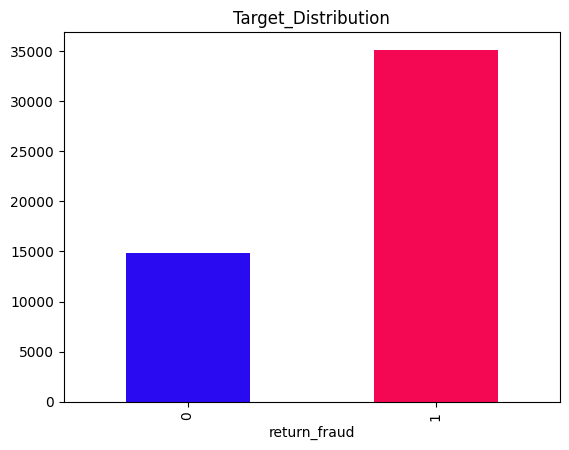

In [81]:
df['return_fraud'].value_counts().sort_index().plot(
    kind='bar', color=["#290AF1", "#F40853"]
)
plt.title('Target_Distribution')
plt.show()

- The dataset is heavily imbalanced — 70.3% fraud (35,132) vs. 29.7% genuine (14,868), a 2.4:1 ratio.
- A naive classifier that always predicts fraud would already hit 70% accuracy, making accuracy alone a misleading metric.
- Precision-recall AUC or F1-score should be used as primary evaluation metrics for this problem.
- Class weights or prediction threshold tuning will be necessary during model training to avoid the model simply predicting the majority class.

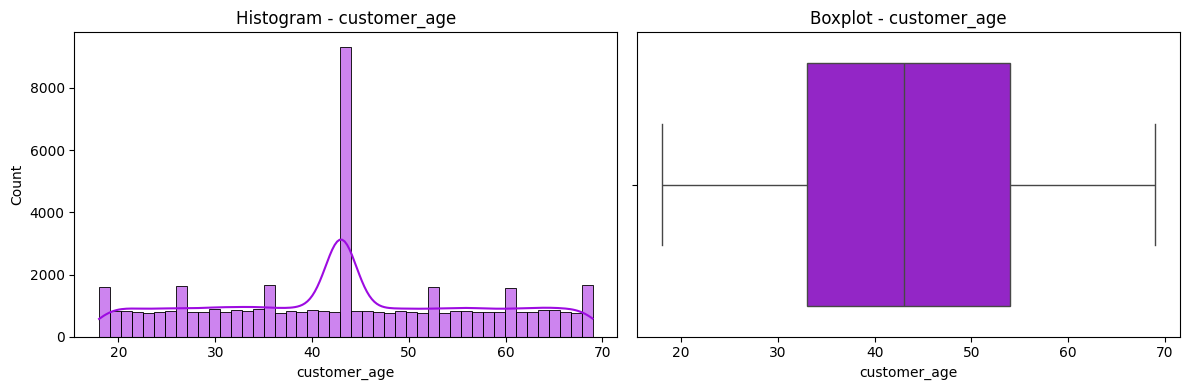


Column: customer_age
count    50000.000000
mean        43.402960
std         13.786825
min         18.000000
25%         33.000000
50%         43.000000
75%         54.000000
max         69.000000
Name: customer_age, dtype: float64
Skewness: 0.03


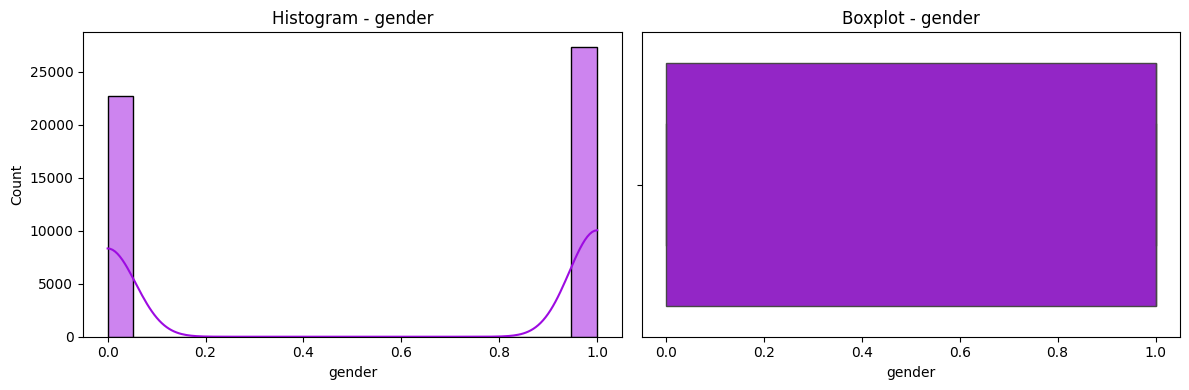


Column: gender
count    50000.000000
mean         0.546680
std          0.497821
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: gender, dtype: float64
Skewness: -0.19
Skipping city_tier - No valid values


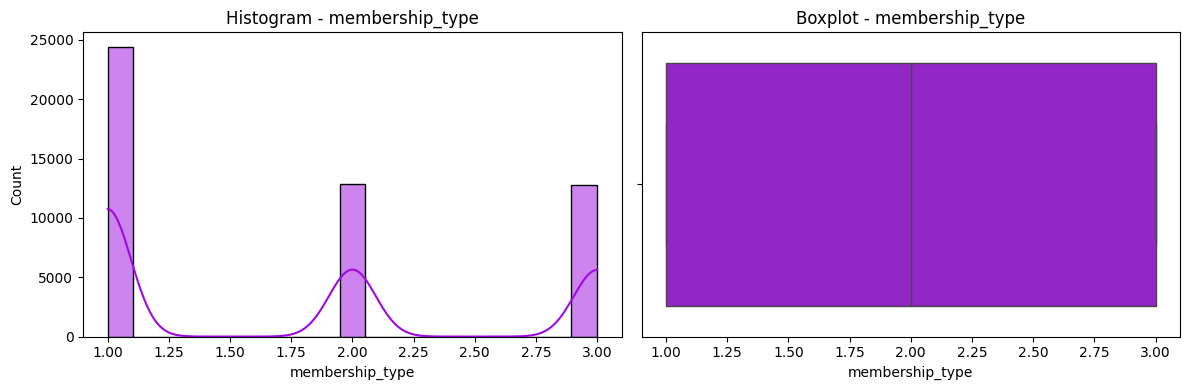


Column: membership_type
count    50000.00000
mean         1.76688
std          0.83015
min          1.00000
25%          1.00000
50%          2.00000
75%          3.00000
max          3.00000
Name: membership_type, dtype: float64
Skewness: 0.46


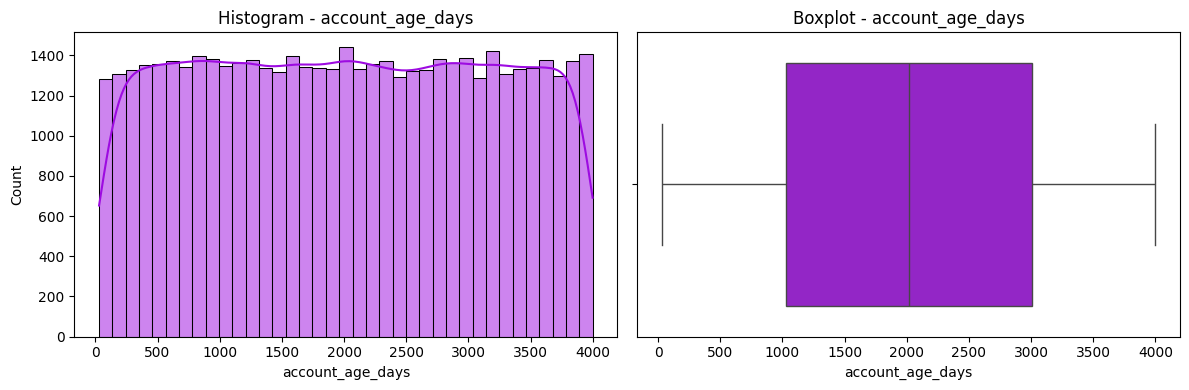


Column: account_age_days
count    50000.000000
mean      2017.321900
std       1144.307562
min         30.000000
25%       1026.000000
50%       2015.000000
75%       3005.000000
max       3999.000000
Name: account_age_days, dtype: float64
Skewness: 0.00


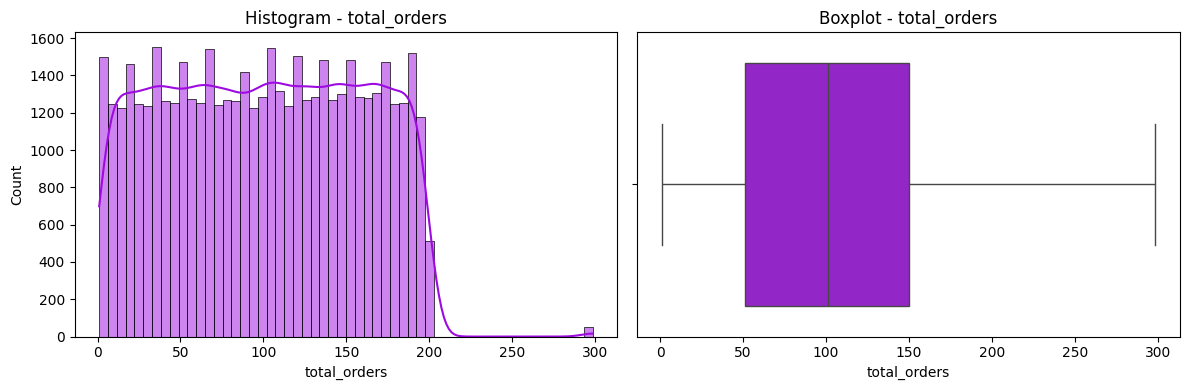


Column: total_orders
count    50000.000000
mean       100.349280
std         57.586675
min          1.000000
25%         51.000000
50%        101.000000
75%        150.000000
max        298.500000
Name: total_orders, dtype: float64
Skewness: 0.02


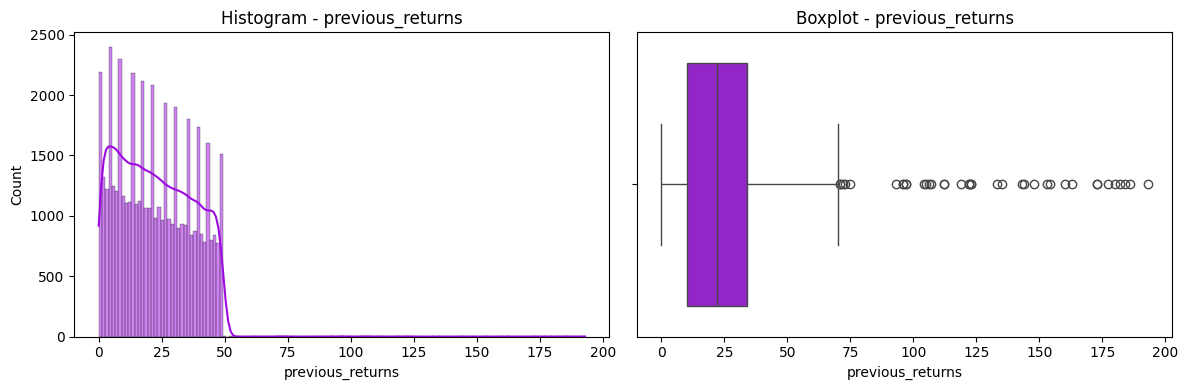


Column: previous_returns
count    50000.000000
mean        22.594580
std         14.573486
min          0.000000
25%         10.000000
50%         22.000000
75%         34.000000
max        193.000000
Name: previous_returns, dtype: float64
Skewness: 0.54


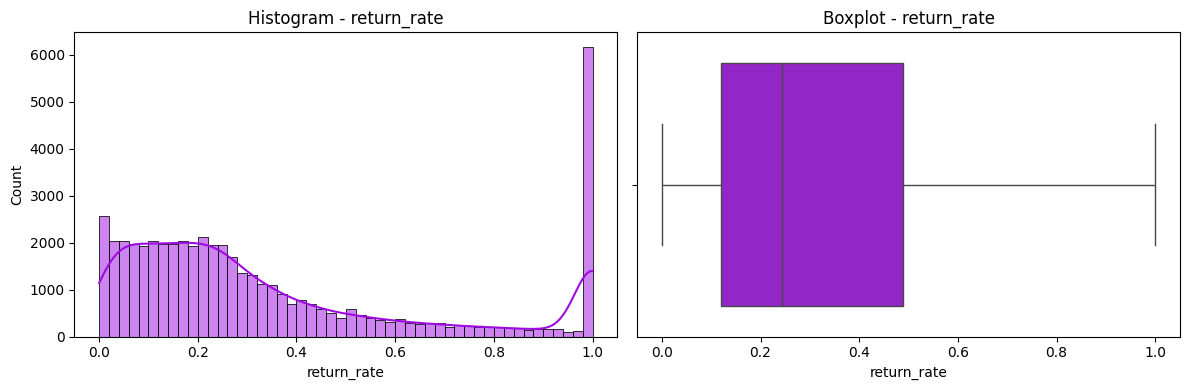


Column: return_rate
count    50000.000000
mean         0.353041
std          0.313921
min          0.000000
25%          0.119000
50%          0.243700
75%          0.488175
max          1.000000
Name: return_rate, dtype: float64
Skewness: 1.03


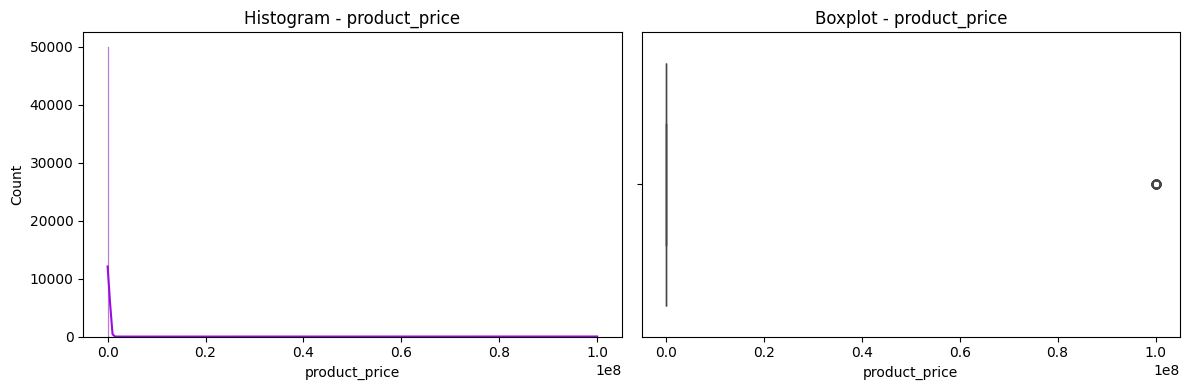


Column: product_price
count    5.000000e+04
mean     1.489745e+05
std      3.159297e+06
min     -5.000000e+03
25%      2.736750e+04
50%      4.905900e+04
75%      7.076450e+04
max      1.000000e+08
Name: product_price, dtype: float64
Skewness: 31.57


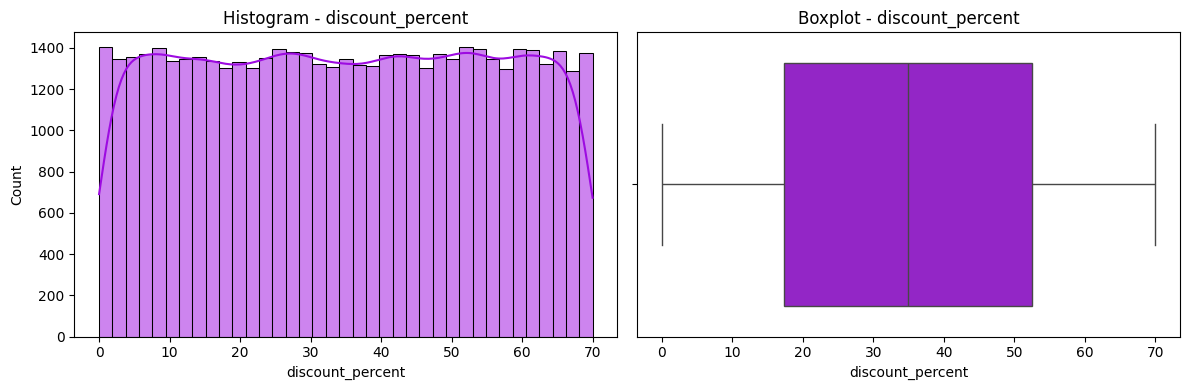


Column: discount_percent
count    50000.000000
mean        34.985108
std         20.250652
min          0.000628
25%         17.368236
50%         34.975805
75%         52.540218
max         69.999952
Name: discount_percent, dtype: float64
Skewness: -0.00


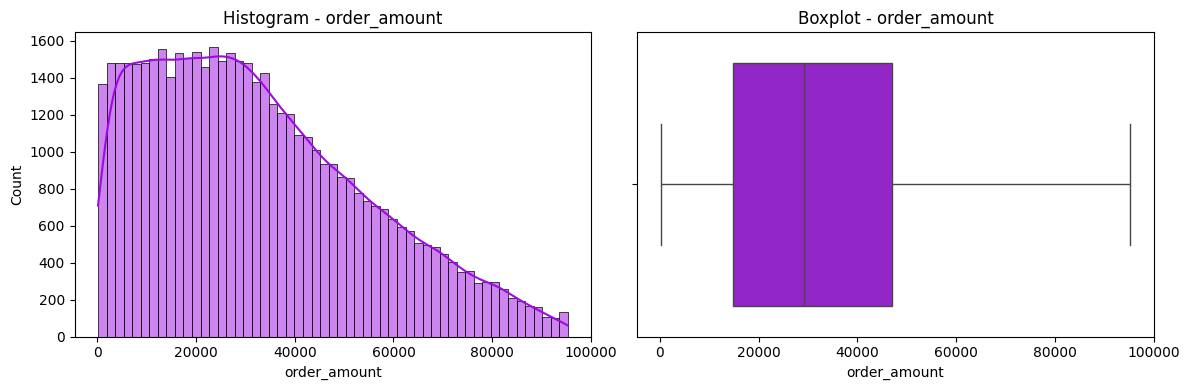


Column: order_amount
count    50000.000000
mean     32645.790255
std      21956.948796
min        162.084289
25%      14833.513566
50%      29139.325674
75%      47023.744096
max      95309.089892
Name: order_amount, dtype: float64
Skewness: 0.62


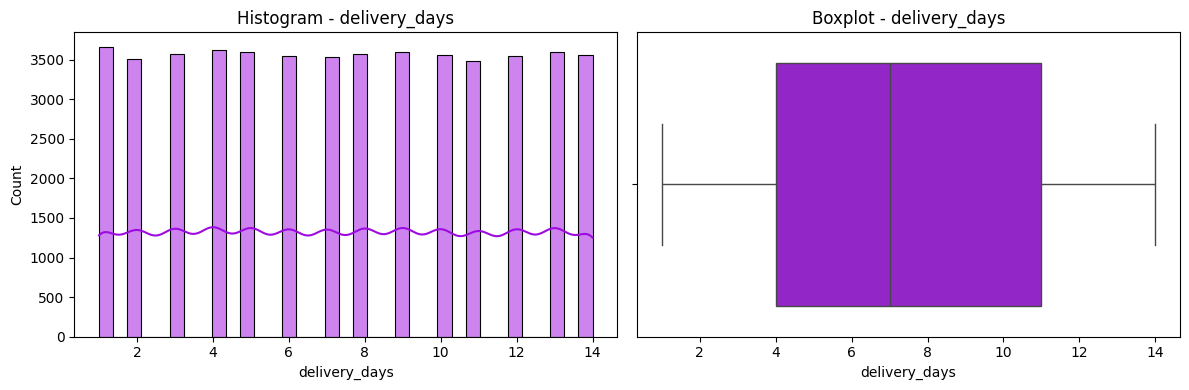


Column: delivery_days
count    50000.000000
mean         7.485020
std          4.036333
min          1.000000
25%          4.000000
50%          7.000000
75%         11.000000
max         14.000000
Name: delivery_days, dtype: float64
Skewness: 0.00


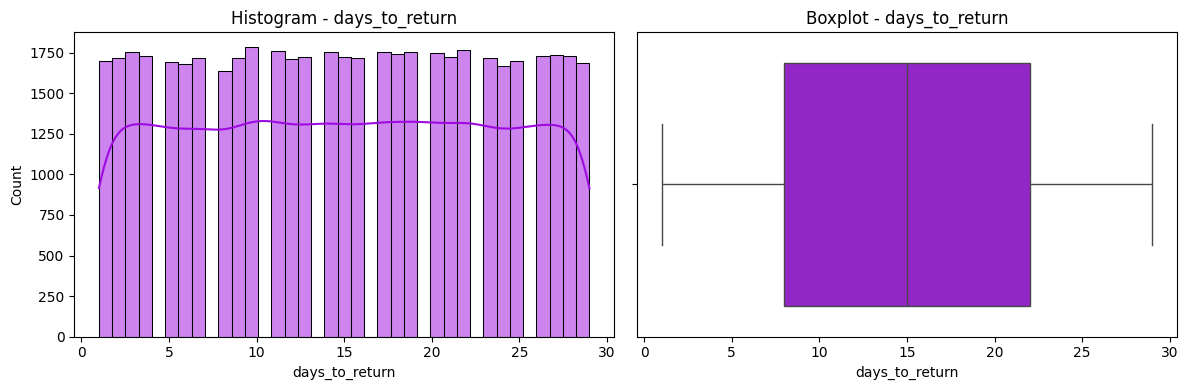


Column: days_to_return
count    50000.000000
mean        15.011040
std          8.345381
min          1.000000
25%          8.000000
50%         15.000000
75%         22.000000
max         29.000000
Name: days_to_return, dtype: float64
Skewness: -0.00


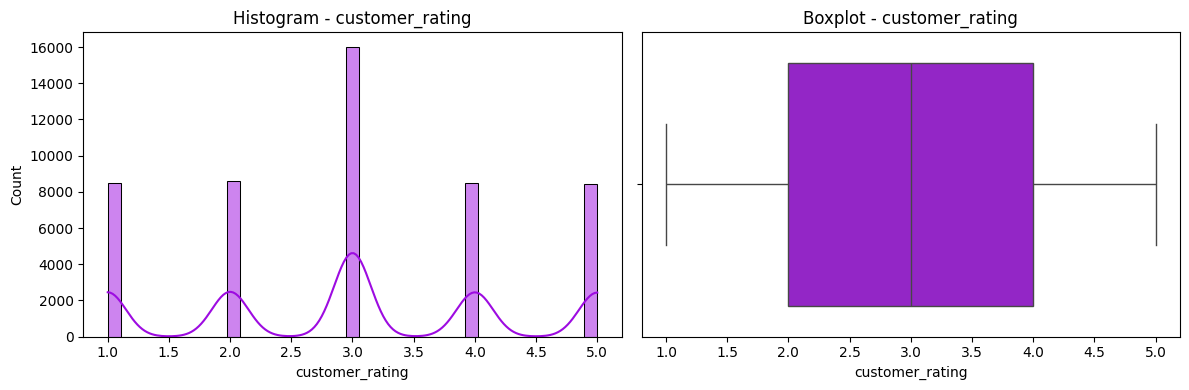


Column: customer_rating
count    50000.000000
mean         2.995780
std          1.302135
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: customer_rating, dtype: float64
Skewness: 0.00


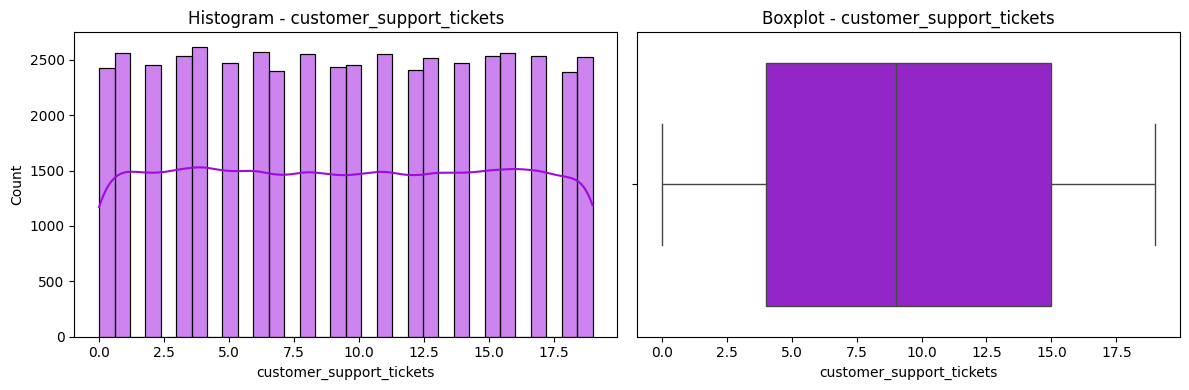


Column: customer_support_tickets
count    50000.000000
mean         9.491360
std          5.766298
min          0.000000
25%          4.000000
50%          9.000000
75%         15.000000
max         19.000000
Name: customer_support_tickets, dtype: float64
Skewness: 0.00


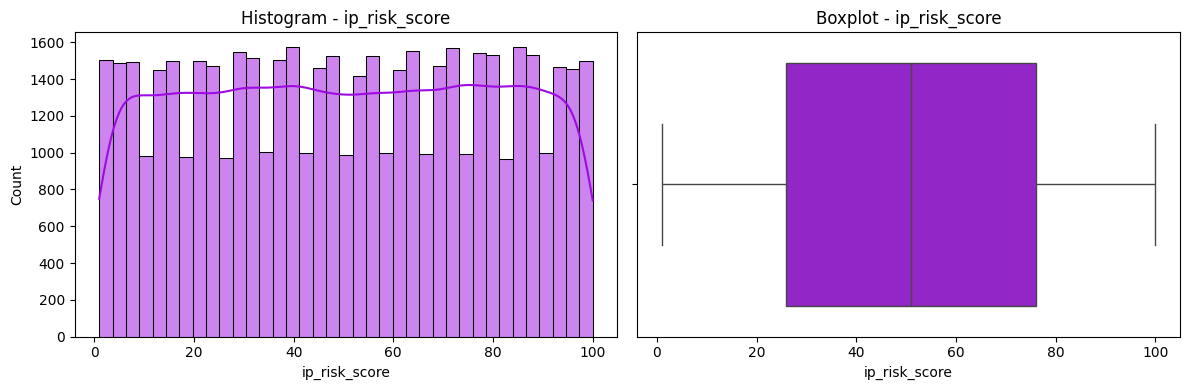


Column: ip_risk_score
count    50000.000000
mean        50.609240
std         28.826026
min          1.000000
25%         26.000000
50%         51.000000
75%         76.000000
max        100.000000
Name: ip_risk_score, dtype: float64
Skewness: -0.01


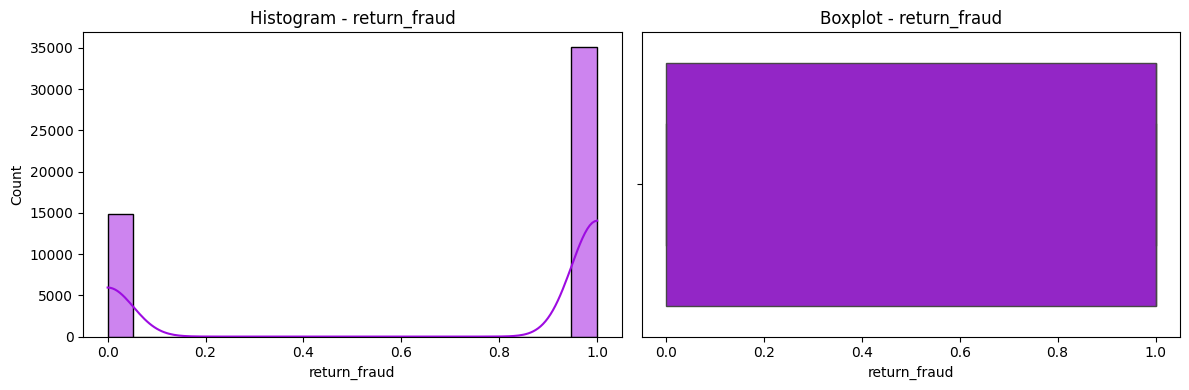


Column: return_fraud
count    50000.000000
mean         0.702640
std          0.457101
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: return_fraud, dtype: float64
Skewness: -0.89


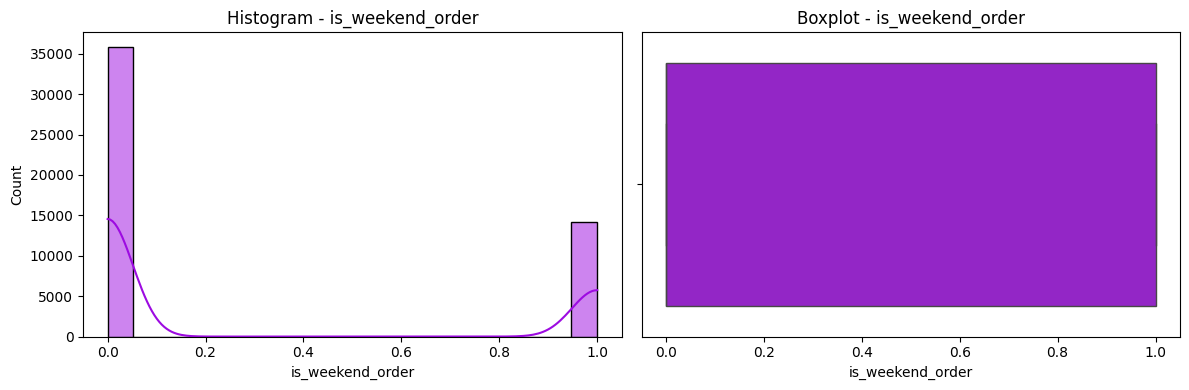


Column: is_weekend_order
count    50000.000000
mean         0.283000
std          0.450461
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: is_weekend_order, dtype: float64
Skewness: 0.96


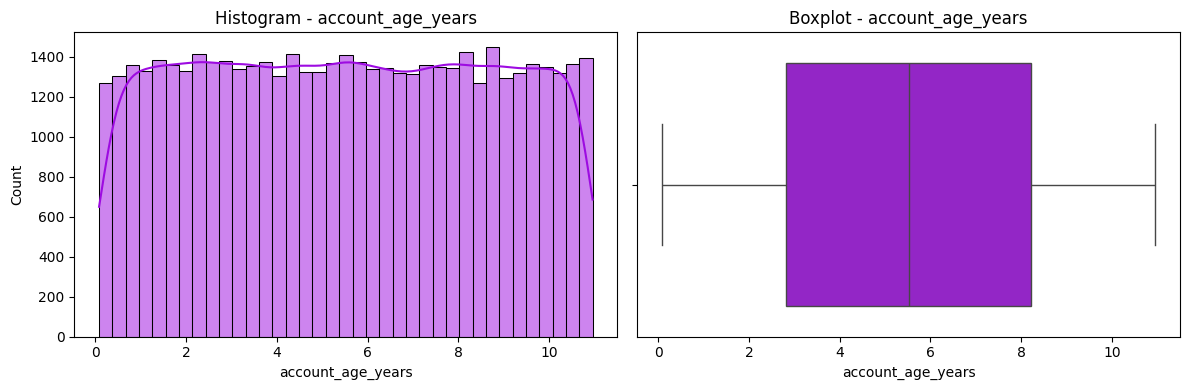


Column: account_age_years
count    50000.000000
mean         5.526906
std          3.135083
min          0.080000
25%          2.810000
50%          5.520000
75%          8.230000
max         10.960000
Name: account_age_years, dtype: float64
Skewness: 0.00


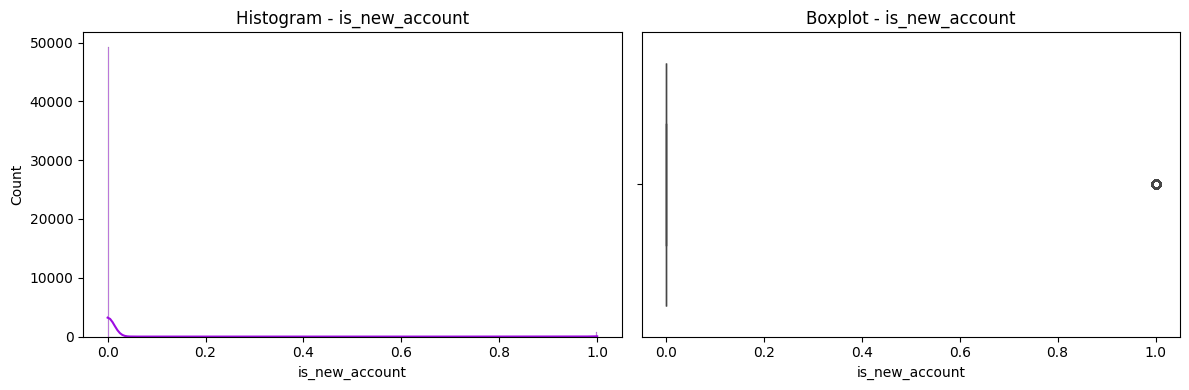


Column: is_new_account
count    50000.000000
mean         0.014280
std          0.118644
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: is_new_account, dtype: float64
Skewness: 8.19


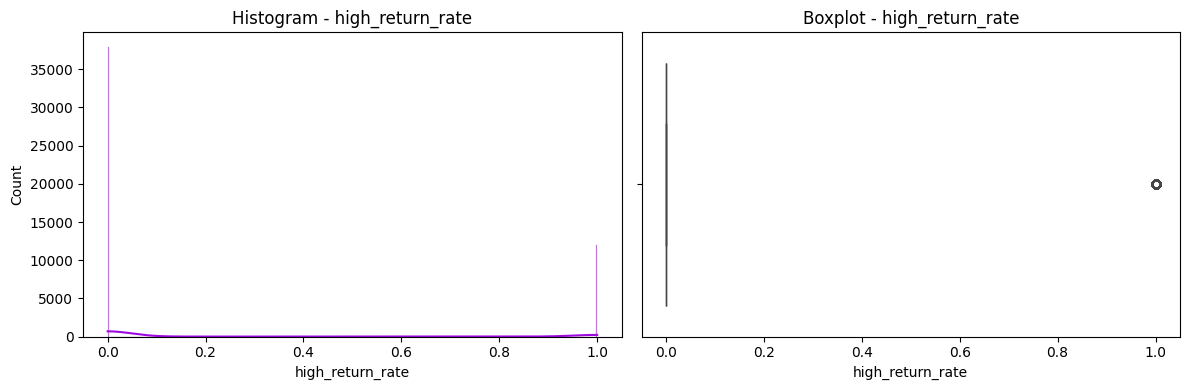


Column: high_return_rate
count    50000.000000
mean         0.241140
std          0.427779
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: high_return_rate, dtype: float64
Skewness: 1.21


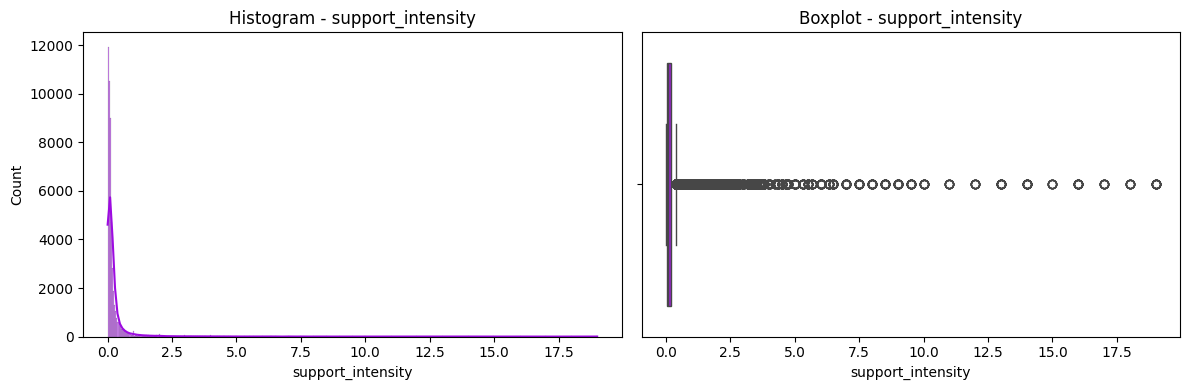


Column: support_intensity
count    50000.000000
mean         0.270607
std          0.904917
min          0.000000
25%          0.044600
50%          0.094900
75%          0.186300
max         19.000000
Name: support_intensity, dtype: float64
Skewness: 11.10


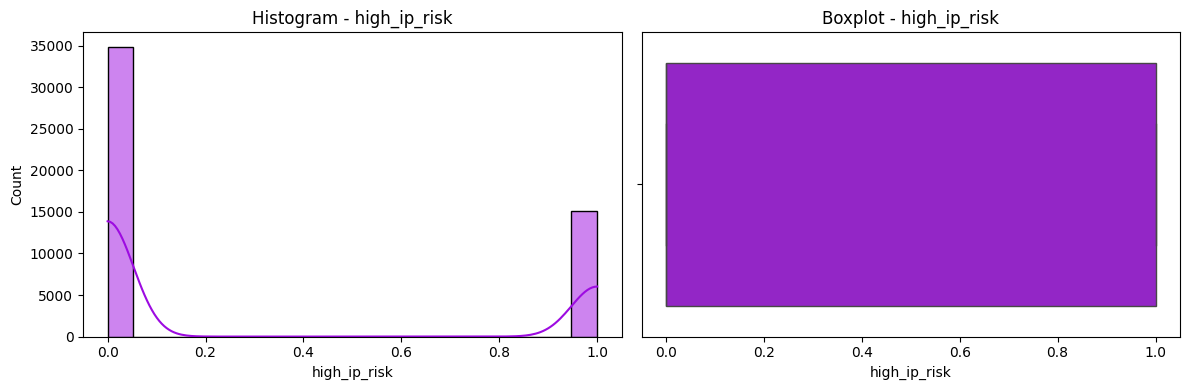


Column: high_ip_risk
count    50000.000000
mean         0.302600
std          0.459388
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: high_ip_risk, dtype: float64
Skewness: 0.86


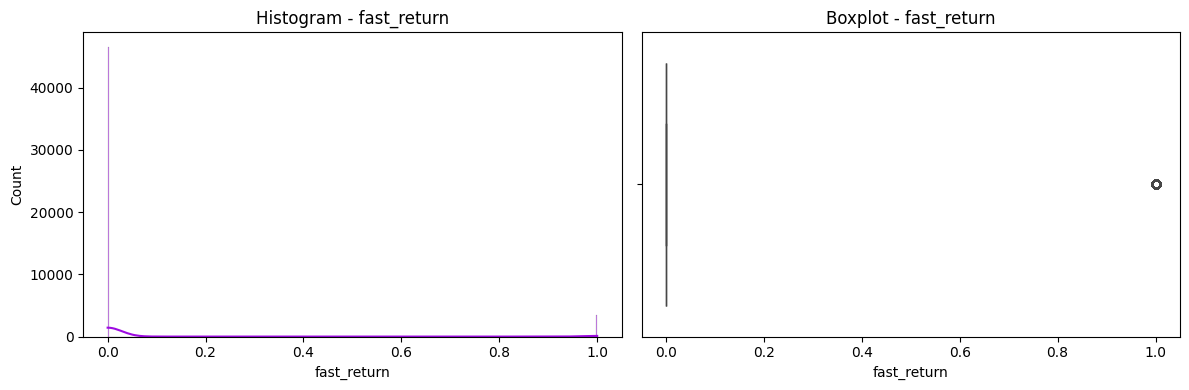


Column: fast_return
count    50000.000000
mean         0.068340
std          0.252331
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: fast_return, dtype: float64
Skewness: 3.42


In [ ]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:

    # Remove NaN and Inf values
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()

    # Skip empty columns
    if len(data) == 0:
        print(f"Skipping {col} - No valid values")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(data, kde=True, ax=axes[0], color="#9D0BE1E0")
    axes[0].set_title(f'Histogram - {col}')

    # Boxplot
    sns.boxplot(x=data, ax=axes[1], color="#9D0BE1E0")
    axes[1].set_title(f'Boxplot - {col}')

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(data.describe())
    print(f"Skewness: {data.skew():.2f}")

- customer_age, account_age_days, delivery_days, and days_to_return are near-uniform or symmetric with skewness ≈ 0 — no transformation needed.
- product_price is the worst outlier with skewness of 31.57 and a negative minimum (−₹5,000), signaling lingering data quality issues even after imputation.
- is_new_account (skew 8.19), support_intensity (skew 11.10), and fast_return (skew 3.42) are heavily right-skewed — these flagged behaviors are genuinely rare events in the data.
- ip_risk_score is near-uniform (skew −0.01), meaning high-risk IPs are just as common as low-risk ones, so no single score range dominates the data.

Fraud rate by return_rate 

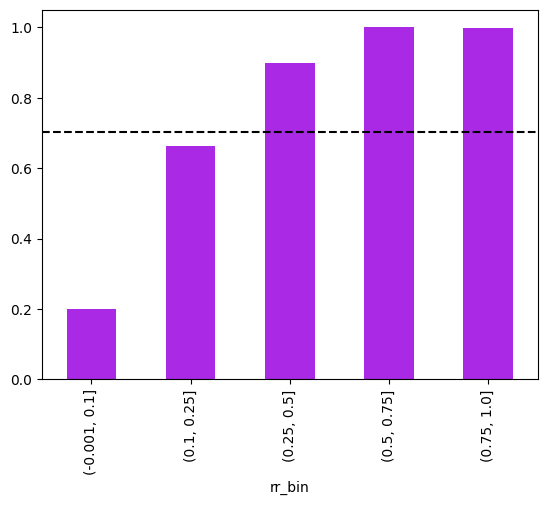

In [117]:
df['rr_bin'] = pd.cut(df['return_rate'], bins=[0, 0.1, 0.25, 0.5, 0.75, 1.0], include_lowest=True)
df.groupby('rr_bin', observed=True)['return_fraud'].mean().plot(kind='bar', color="#9D0BE1E0")
plt.axhline(0.703, color='black', ls='--')
plt.show()

1. Customers with a **return rate below 10%** show only **20% fraud**, indicating mostly genuine behavior.

2. Fraud rate increases sharply to **66%** when the return rate rises to **10%–25%**.

3. Customers returning **25%–50%** of their orders have a very high **90% fraud rate**.

4. Fraud reaches **100%** for customers with return rates between **50% and 75%**.

5. Customers returning **more than 75%** of their orders also show **100% fraud**, making them extremely high risk.

6. Overall, the chart shows a **strong positive relationship between return rate and fraud**, suggesting that return rate is a key indicator of fraudulent activity.



Fraud rate by product category

In [96]:
product_cols = [col for col in df.columns if col.startswith('product_category_')]

df['product_category'] = (
    df[product_cols]
    .idxmax(axis=1)
    .str.replace('product_category_', '')
)

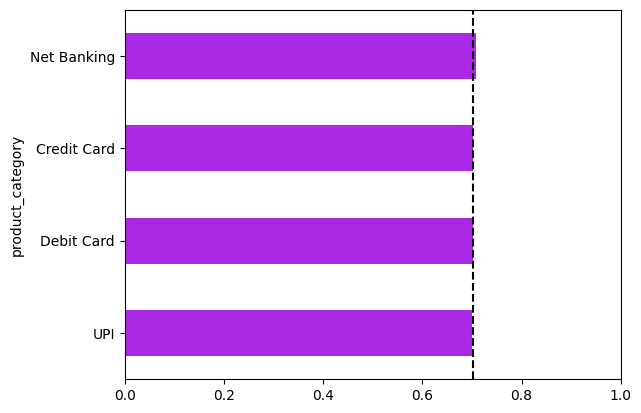

In [118]:
df.groupby('product_category')['return_fraud'] \
  .mean() \
  .sort_values() \
  .plot(kind='barh', color="#9D0BE1E0")

plt.axvline(0.703, color='black', ls='--')
plt.xlim(0, 1)      
plt.show()

- All six product categories fall within a 1.2 percentage point band — Electronics at 69.5% and Mobile at 70.7% fraud rate, both essentially at the dataset average of 70.3%.
- No category is meaningfully over- or under-represented among fraud cases; the spread is too small to be actionable.
- Fraudsters appear to target all product types equally, which is consistent with return fraud being a behavior-driven rather than product-driven pattern.
- Product category is unlikely to add predictive power to the model and may be dropped if feature selection is applied.

Fraud rate by payment method

In [108]:
product_cols = [col for col in df.columns if col.startswith('payment_method_')]

df['payment_method'] = (
    df[product_cols]
    .idxmax(axis=1)
    .str.replace('payment_method_', '')
)

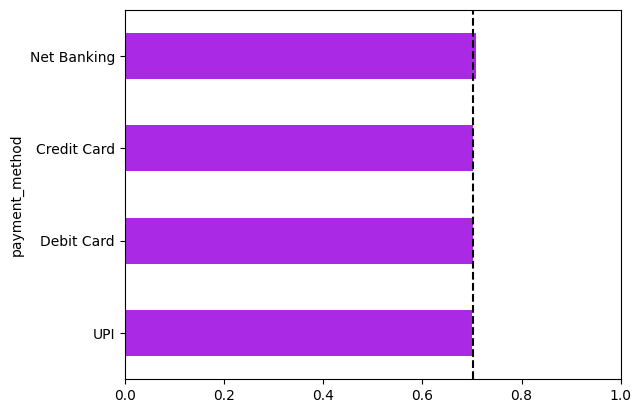

In [119]:
df.groupby('payment_method')['return_fraud'] \
  .mean() \
  .sort_values() \
  .plot(kind='barh', color="#9D0BE1E0")

plt.axvline(0.703, color='black', ls='--')
plt.xlim(0, 1)      
plt.show()

- All five payment methods cluster within a 0.8-point range: UPI and Credit Card at 70.0%, Net Banking highest at 70.8% — all within noise of the overall 70.3% rate.
- Cash on Delivery sits at 70.4%, barely above average, which contradicts the common assumption that COD is more fraud-prone.
- The spread across payment methods is the narrowest of any categorical breakdown examined so far.
- Like product category, payment method shows near-zero discriminatory power and contributes minimal signal for separating fraudsters from genuine customers.

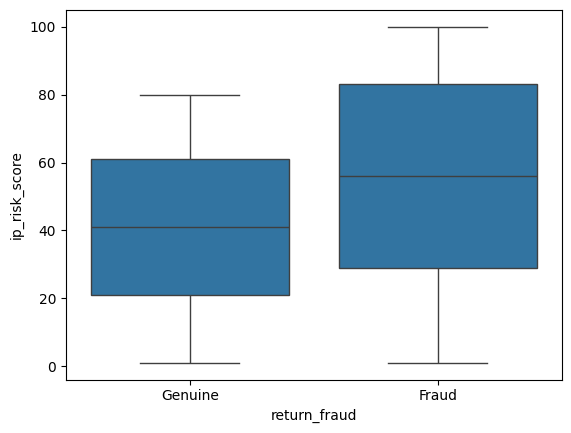

In [110]:
sns.boxplot(data=df, x='return_fraud', y='ip_risk_score')
plt.xticks([0, 1], ['Genuine', 'Fraud'])
plt.show()

- Genuine orders have a median IP risk score of 41 vs. 56 for fraudulent orders — a clear 15-point separation visible in the box centers.
- The IQR for genuine orders runs 21–61, while fraudsters span 29–83, with fraud cases reaching the maximum score of 100.
- The upward shift in both the median and the upper whisker confirms that higher IP risk scores consistently track with fraud.
- Overlap between distributions is still substantial, so ip_risk_score alone isn't a decision rule — but it should rank among the top features in importance.

Corelation heatmap

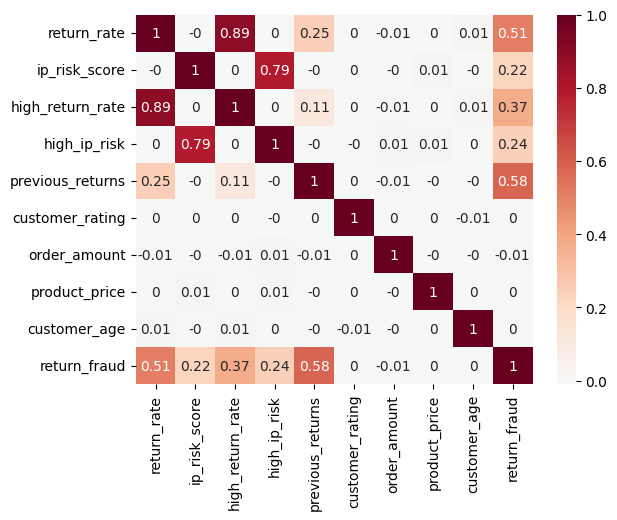

In [111]:
num = ['return_rate','ip_risk_score','high_return_rate','high_ip_risk','previous_returns',
       'customer_rating','order_amount','product_price','customer_age','return_fraud']
sns.heatmap(df[num].corr().round(2), annot=True, cmap='RdBu_r', center=0)
plt.show()

- return_rate and high_return_rate are perfectly correlated by construction — high_return_rate is just a binary threshold on return_rate, so they carry identical information.
- ip_risk_score and high_ip_risk follow the same derived relationship and will behave identically in a linear model.
- return_fraud shows the strongest positive links with return_rate and ip_risk_score — these are the two clearest fraud signals in the numeric feature set.
- customer_rating, order_amount, and product_price all sit near zero correlation with the target — confirming they are low-signal features unlikely to drive model decisions.
- previous_returns correlates with return_rate but not perfectly, since total_orders also factors into the rate calculation.